In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.model_selection import train_test_split

In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Input,LSTM,Dense
from tensorflow import keras as kr
from tensorflow.keras import models
from tensorflow.keras import layers,models,datasets

In [3]:
d=kr.datasets.mnist
(x_train,y_train),(x_test,y_test)=d.load_data()
x_train,x_test=x_train/255.0,x_test/255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
input_shape=(28,28)
inputs=Input(shape=input_shape)
rnn=LSTM(128)(inputs)
outputs=Dense(10,activation='softmax')(rnn)
model=models.Model(inputs=inputs,outputs=outputs)

In [5]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        80,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,674 (319.04 KB)

 Trainable params: 81,674 (319.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer="adam",
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
model=model.fit(x_train,y_train,validation_split=0.1,epochs=10)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 67s 39ms/step - accuracy: 0.8879 - loss: 0.3497 - val_accuracy: 0.9612 - val_loss: 0.1208
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 63s 37ms/step - accuracy: 0.9671 - loss: 0.1093 - val_accuracy: 0.9745 - val_loss: 0.0892
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 64s 38ms/step - accuracy: 0.9769 - loss: 0.0761 - val_accuracy: 0.9787 - val_loss: 0.0672
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 83s 38ms/step - accuracy: 0.9825 - loss: 0.0584 - val_accuracy: 0.9728 - val_loss: 0.0855
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 66s 39ms/step - accuracy: 0.9858 - loss: 0.0488 - val_accuracy: 0.9858 - val_loss: 0.0503
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 64s 38ms/step - accuracy: 0.9868 - loss: 0.0426 - val_accuracy: 0.9867 - val_loss: 0.0433
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - accuracy: 0.9898 - loss: 0.0328 - val_accuracy: 0.9872 - val_loss: 0.0458
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 64s 38ms/step - accuracy: 0.9906 -

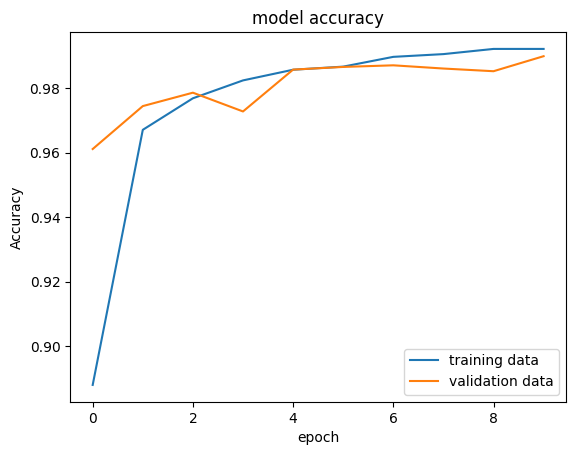

In [8]:
plt.plot(model.history["accuracy"])
plt.plot(model.history['val_accuracy'])
plt.title("model accuracy")
plt.xlabel("epoch")
plt.ylabel("Accuracy")
plt.legend(['training data','validation data'],loc='lower right')

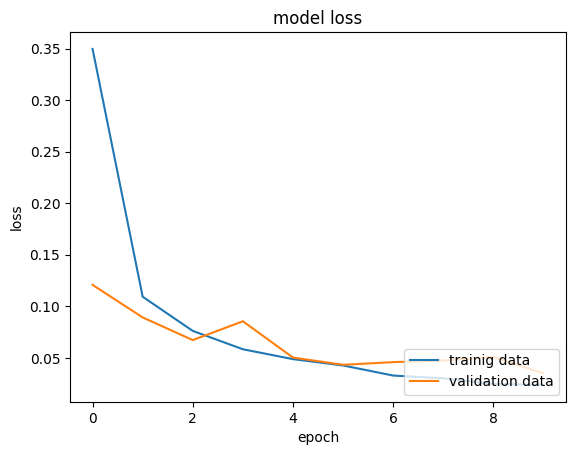

In [9]:
plt.plot(model.history['loss'])
plt.plot(model.history['val_loss'])
plt.title("model loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(['trainig data','validation data'],loc='lower right')